# Variance Structure Analysis: Converters vs Non-Converters

This notebook analyzes the variance structure of connectivity data to check if within-group variance dominates between-group variance for **Converters vs Non-Converters**.

**Goal:**
Check if the reconstruction loss problem exists for the Converters vs Non-Converters classification task by computing the variance ratio for all correlation types.

**Groups:**
- **Converters:** MCI subjects who converted to AD
- **Non-Converters:** Healthy + MCI-stable subjects combined

**Analysis:**
For each correlation type, we compute:
- Within-group variance: Mean of variances within each group
- Between-group variance: Variance of group means
- Variance Ratio = Between-group variance / Within-group variance

A low ratio (<< 1) indicates that individual variation dominates disease-related signal.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

sys.path.append('/mnt/e/fyassine/ad-early-detection')
import config
from model.data_understanding.statistical_tests.import_utils import load_and_process_cohorts

## 1. Load Data for All Correlation Types

In [2]:
correlation_types = ['pearson', 'spearman', 'kendall', 'riemannian', 'xcorr']
all_data = {}

for corr_type in correlation_types:
    print(f"\nLoading {corr_type.upper()} data...")
    try:
        cohorts = load_and_process_cohorts(config, correlation_type=corr_type, remove_nan=True)
        all_data[corr_type] = cohorts
    except Exception as e:
        print(f"Failed to load {corr_type}: {e}")


Loading PEARSON data...
Healthy: 201 subjects, Matrix shape: (201, 110, 110), Edges shape: (201, 5995)
AD: 104 subjects, Matrix shape: (104, 110, 110), Edges shape: (104, 5995)
MCI: 533 subjects, Matrix shape: (533, 110, 110), Edges shape: (533, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)

Loading SPEARMAN data...
Healthy: Removing 13 subjects with NaN values.
Healthy: 188 subjects, Matrix shape: (188, 110, 110), Edges shape: (188, 5995)
AD: Removing 11 subjects with NaN values.
AD: 93 subjects, Matrix shape: (93, 110, 110), Edges shape: (93, 5995)
MCI: Removing 29 subjects with NaN values.
MCI: 504 subjects, Matrix shape: (504, 110, 110), Edges shape: (504, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)

Loading KENDALL data...
Healthy: Removing 13 subjects with NaN values.
Healthy: 188 subjects, Matrix shape: (188, 110, 110), Edges shape: (188, 5995)
AD: Removing 11 subjects with NaN values.
AD: 93 subjec

## 2. Variance Structure Analysis: Converters vs Non-Converters

For each correlation type, we compute the variance ratio to understand if between-group differences are strong enough compared to within-group variation.

**Formula:**
- $\sigma^2_{within} = \frac{\sigma^2_{converters} + \sigma^2_{non-converters}}{2}$
- $\sigma^2_{between} = \text{Var}(\mu_{converters}, \mu_{non-converters})$
- $\text{Variance Ratio} = \frac{\sigma^2_{between}}{\sigma^2_{within}}$

**Interpretation:**
- Ratio >> 1: Groups are well-separated, disease signal dominates
- Ratio << 1: Individual variation dominates, reconstruction loss will learn noise
- Ratio ≈ 0.006 (as in reference): Within-group variance is ~150× larger than between-group

In [3]:
results = []

for corr_type, cohorts in all_data.items():
    print(f"\nAnalyzing Variance for {corr_type.upper()}...")
    
    converter_edges = cohorts['converter']['edges']
    non_converter_edges = np.vstack([
        cohorts['healthy']['edges'],
        cohorts['mci']['edges']
    ])
    
    n_converters = converter_edges.shape[0]
    n_non_converters = non_converter_edges.shape[0]
    print(f"  Converters: {n_converters} subjects")
    print(f"  Non-Converters: {n_non_converters} subjects")
    
    means_converter = np.mean(converter_edges, axis=0)
    vars_converter = np.var(converter_edges, axis=0, ddof=1)
    
    means_non_converter = np.mean(non_converter_edges, axis=0)
    vars_non_converter = np.var(non_converter_edges, axis=0, ddof=1)
    
    within_group_var = (vars_converter + vars_non_converter) / 2
    
    group_means = np.vstack([means_converter, means_non_converter])
    between_group_var = np.var(group_means, axis=0, ddof=1)
    
    epsilon = 1e-10
    variance_ratio = between_group_var / (within_group_var + epsilon)
    
    mean_within = np.mean(within_group_var)
    mean_between = np.mean(between_group_var)
    avg_ratio = np.mean(variance_ratio)
    median_ratio = np.median(variance_ratio)
    max_ratio = np.max(variance_ratio)
    count_ratio_gt_1 = np.sum(variance_ratio > 1.0)
    count_ratio_gt_01 = np.sum(variance_ratio > 0.1)
    
    print(f"  Mean Within-Group Variance: {mean_within:.6f}")
    print(f"  Mean Between-Group Variance: {mean_between:.6f}")
    print(f"  Mean Variance Ratio: {avg_ratio:.6f}")
    print(f"  Edges with Ratio > 1.0: {count_ratio_gt_1} ({100*count_ratio_gt_1/len(variance_ratio):.2f}%)")
    print(f"  Edges with Ratio > 0.1: {count_ratio_gt_01} ({100*count_ratio_gt_01/len(variance_ratio):.2f}%)")
    
    results.append({
        'Correlation': corr_type,
        'Mean Within-Var': mean_within,
        'Mean Between-Var': mean_between,
        'Mean Ratio': avg_ratio,
        'Median Ratio': median_ratio,
        'Max Ratio': max_ratio,
        'Edges > 1.0': count_ratio_gt_1,
        'Edges > 0.1': count_ratio_gt_01,
        '% > 1.0': 100 * count_ratio_gt_1 / len(variance_ratio)
    })


Analyzing Variance for PEARSON...
  Converters: 60 subjects
  Non-Converters: 734 subjects
  Mean Within-Group Variance: 0.032396
  Mean Between-Group Variance: 0.000523
  Mean Variance Ratio: 0.015660
  Edges with Ratio > 1.0: 0 (0.00%)
  Edges with Ratio > 0.1: 54 (0.90%)

Analyzing Variance for SPEARMAN...


  Converters: 60 subjects
  Non-Converters: 692 subjects
  Mean Within-Group Variance: 0.037320
  Mean Between-Group Variance: 0.000590
  Mean Variance Ratio: 0.015345
  Edges with Ratio > 1.0: 0 (0.00%)
  Edges with Ratio > 0.1: 55 (0.92%)

Analyzing Variance for KENDALL...
  Converters: 60 subjects
  Non-Converters: 692 subjects
  Mean Within-Group Variance: 0.017725
  Mean Between-Group Variance: 0.000282
  Mean Variance Ratio: 0.015429
  Edges with Ratio > 1.0: 0 (0.00%)
  Edges with Ratio > 0.1: 58 (0.97%)

Analyzing Variance for RIEMANNIAN...
  Converters: 60 subjects
  Non-Converters: 734 subjects
  Mean Within-Group Variance: 558876909586.458252
  Mean Between-Group Variance: 4342317377.978059
  Mean Variance Ratio: 0.006652
  Edges with Ratio > 1.0: 0 (0.00%)
  Edges with Ratio > 0.1: 1 (0.02%)

Analyzing Variance for XCORR...
  Converters: 60 subjects
  Non-Converters: 734 subjects
  Mean Within-Group Variance: 0.005998
  Mean Between-Group Variance: 0.000086
  Mean Variance 

In [4]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Mean Ratio', ascending=False)
print("\n=== VARIANCE STRUCTURE ANALYSIS SUMMARY ===")
print(df_results.to_markdown(index=False))


=== VARIANCE STRUCTURE ANALYSIS SUMMARY ===
| Correlation   |   Mean Within-Var |   Mean Between-Var |   Mean Ratio |   Median Ratio |   Max Ratio |   Edges > 1.0 |   Edges > 0.1 |   % > 1.0 |
|:--------------|------------------:|-------------------:|-------------:|---------------:|------------:|--------------:|--------------:|----------:|
| pearson       |       0.0323965   |        0.000523066 |   0.0156605  |     0.00755963 |    0.192849 |             0 |            54 |         0 |
| kendall       |       0.017725    |        0.000282478 |   0.0154289  |     0.0074738  |    0.210153 |             0 |            58 |         0 |
| spearman      |       0.0373202   |        0.000589501 |   0.0153453  |     0.00739351 |    0.209878 |             0 |            55 |         0 |
| xcorr         |       0.00599764  |        8.64767e-05 |   0.0129848  |     0.0059147  |    0.177337 |             0 |            38 |         0 |
| riemannian    |       5.58877e+11 |        4.34232e+09 |   

In [5]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Mean Ratio', ascending=False)

print("\n" + "="*80)
print("VARIANCE STRUCTURE ANALYSIS: CONVERTERS VS NON-CONVERTERS")
print("="*80)
print(df_results.to_string(index=False))
print("\n" + "="*80)

print("\n📊 KEY FINDINGS:")
print(f"   • Best correlation type: {df_results.iloc[0]['Correlation'].upper()} (ratio: {df_results.iloc[0]['Mean Ratio']:.6f})")
print(f"   • Worst correlation type: {df_results.iloc[-1]['Correlation'].upper()} (ratio: {df_results.iloc[-1]['Mean Ratio']:.6f})")

max_pct = df_results['% > 1.0'].max()
if max_pct == 0:
    print(f"\n⚠️  CRITICAL: NO edges have variance ratio > 1.0 for ANY correlation type")
    print(f"   → Within-group variance dominates for 100% of edges")
    print(f"   → Reconstruction loss will learn individual noise, not disease patterns")
else:
    print(f"\n   • Maximum % edges with ratio > 1.0: {max_pct:.2f}%")

mean_ratio_avg = df_results['Mean Ratio'].mean()
if mean_ratio_avg < 0.01:
    factor = 1.0 / mean_ratio_avg
    print(f"\n⚠️  Average variance ratio across all types: {mean_ratio_avg:.6f}")
    print(f"   → Within-group variance is ~{factor:.0f}× larger than between-group variance")
    print(f"   → The reconstruction loss problem EXISTS for Converters vs Non-Converters")


VARIANCE STRUCTURE ANALYSIS: CONVERTERS VS NON-CONVERTERS
Correlation  Mean Within-Var  Mean Between-Var  Mean Ratio  Median Ratio  Max Ratio  Edges > 1.0  Edges > 0.1  % > 1.0
    pearson     3.239649e-02      5.230659e-04    0.015660      0.007560   0.192849            0           54      0.0
    kendall     1.772499e-02      2.824783e-04    0.015429      0.007474   0.210153            0           58      0.0
   spearman     3.732016e-02      5.895014e-04    0.015345      0.007394   0.209878            0           55      0.0
      xcorr     5.997644e-03      8.647675e-05    0.012985      0.005915   0.177337            0           38      0.0
 riemannian     5.588769e+11      4.342317e+09    0.006652      0.001546   0.119696            0            1      0.0


📊 KEY FINDINGS:
   • Best correlation type: PEARSON (ratio: 0.015660)
   • Worst correlation type: RIEMANNIAN (ratio: 0.006652)

⚠️  CRITICAL: NO edges have variance ratio > 1.0 for ANY correlation type
   → Within-group vari

## 4. Summary and Interpretation

Let's summarize the findings across all correlation types.

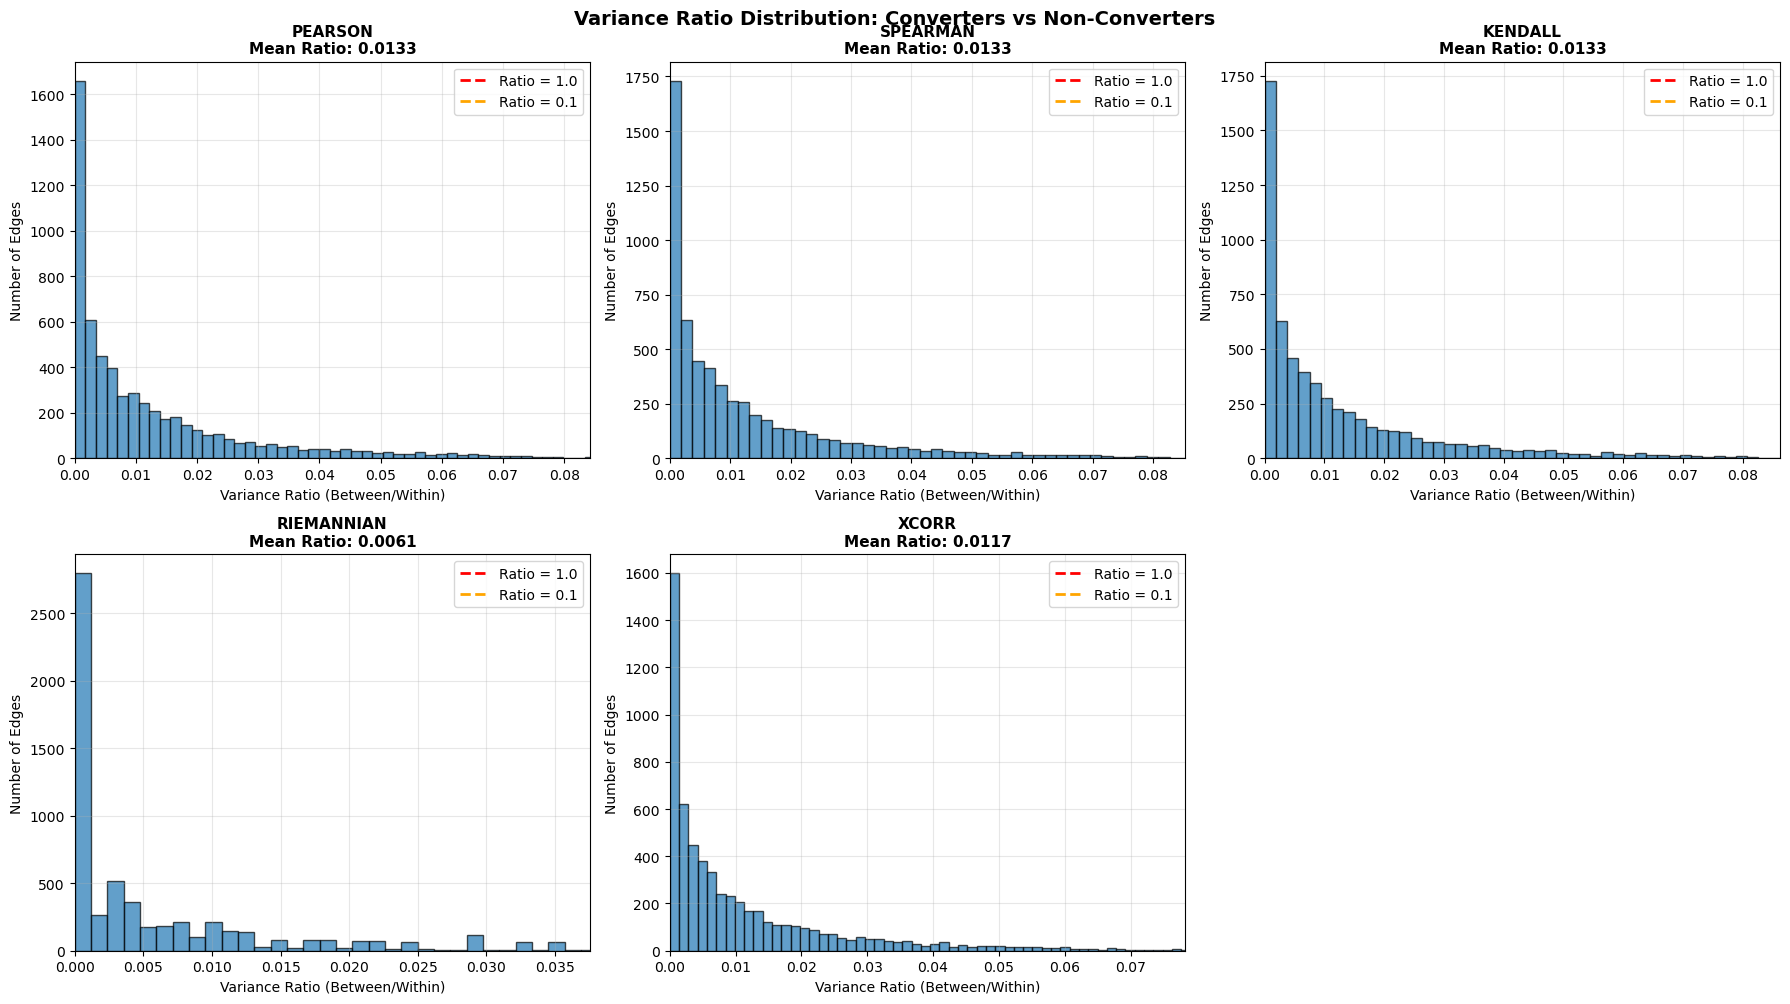

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, corr_type in enumerate(correlation_types):
    cohorts = all_data[corr_type]
    
    converter_edges = cohorts['converter']['edges']
    non_converter_edges = np.vstack([
        cohorts['healthy']['edges'],
        cohorts['ad']['edges'],
        cohorts['mci']['edges']
    ])
    
    means_converter = np.mean(converter_edges, axis=0)
    vars_converter = np.var(converter_edges, axis=0, ddof=1)
    
    means_non_converter = np.mean(non_converter_edges, axis=0)
    vars_non_converter = np.var(non_converter_edges, axis=0, ddof=1)
    
    within_group_var = (vars_converter + vars_non_converter) / 2
    group_means = np.vstack([means_converter, means_non_converter])
    between_group_var = np.var(group_means, axis=0, ddof=1)
    
    variance_ratio = between_group_var / (within_group_var + 1e-10)
    
    ax = axes[idx]
    ax.hist(variance_ratio, bins=100, alpha=0.7, edgecolor='black')
    ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0')
    ax.axvline(x=0.1, color='orange', linestyle='--', linewidth=2, label='Ratio = 0.1')
    ax.set_xlabel('Variance Ratio (Between/Within)', fontsize=10)
    ax.set_ylabel('Number of Edges', fontsize=10)
    ax.set_title(f'{corr_type.upper()}\nMean Ratio: {np.mean(variance_ratio):.4f}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    ax.set_xlim([0, min(1.5, np.percentile(variance_ratio, 99))])

axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Variance Ratio Distribution: Converters vs Non-Converters', fontsize=14, fontweight='bold', y=1.00)
plt.show()